In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, warnings
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
warnings.filterwarnings('ignore')


In [2]:
BASE_PATH = '/Users/vishnu.gorur/PycharmProjects/JupyterProject/data/real_data'
TRAIN_CUTOFF = pd.Timestamp('2024-01-01')
FORECAST_START = pd.Timestamp('2024-01-01')
FORECAST_END = pd.Timestamp('2025-01-01')

df = pd.read_csv(f'{BASE_PATH}/No_leakage_Active_COPA_data.csv', parse_dates=['WAC_PRICE_COPA_DATE'])
df = df[df['IS_FUTURE_PERIOD_FLAG'] == 0].copy()
df['COPA_MTRL_NUM'] = df['COPA_MTRL_NUM'].astype(str).str.zfill(18)
df = df.sort_values(['COPA_MTRL_NUM', 'WAC_PRICE_COPA_DATE', 'BASELINE_WAC_PRICE'])

agg_map = {col: 'first' for col in df.columns if col not in ['COPA_MTRL_NUM', 'WAC_PRICE_COPA_DATE', 'BASELINE_WAC_PRICE']}
agg_map['BASELINE_WAC_PRICE'] = 'min'
df = df.groupby(['COPA_MTRL_NUM', 'WAC_PRICE_COPA_DATE'], as_index=False).agg(agg_map)

baseline_features = pd.read_csv(
    f'{BASE_PATH}/Baseline_model_input.csv',
    usecols=['MTRL_NUM', 'THERAPEUTIC_CLASS', 'MANUFACTURER_NAME']
)
baseline_features['MTRL_NUM'] = baseline_features['MTRL_NUM'].astype(str).str.zfill(18)
baseline_features = baseline_features.drop_duplicates(subset=['MTRL_NUM'])

df = df.merge(
    baseline_features,
    left_on='COPA_MTRL_NUM',
    right_on='MTRL_NUM',
    how='left'
).drop(columns=['MTRL_NUM'])

history_counts = (
    df[df['WAC_PRICE_COPA_DATE'] < TRAIN_CUTOFF]
    .groupby('COPA_MTRL_NUM')['WAC_PRICE_COPA_DATE']
    .nunique()
)
eligible_materials = history_counts[history_counts >= 24].index
df = df[df['COPA_MTRL_NUM'].isin(eligible_materials)].copy()
df = df.sort_values(['COPA_MTRL_NUM', 'WAC_PRICE_COPA_DATE']).reset_index(drop=True)

print(f'Prepared rows: {len(df):,}')
print(f'Eligible materials: {df["COPA_MTRL_NUM"].nunique():,}')
print(f'Date range: {df["WAC_PRICE_COPA_DATE"].min().date()} -> {df["WAC_PRICE_COPA_DATE"].max().date()}')


Prepared rows: 190,664
Eligible materials: 3,658
Date range: 2022-01-01 -> 2026-05-01


In [3]:
INCREASE_THRESHOLD = 0.005
grouped_price = df.groupby('COPA_MTRL_NUM')['BASELINE_WAC_PRICE']

for lag in [1, 2, 3, 6, 12]:
    df[f'lag_{lag}'] = grouped_price.shift(lag)

shifted_price = grouped_price.shift(1)
# Use min_periods=1 so 2022 rows (with short history) are retained — NaNs forward-filled below
df['rolling_mean_3']  = shifted_price.rolling(3,  min_periods=1).mean().reset_index(level=0, drop=True)
df['rolling_mean_6']  = shifted_price.rolling(6,  min_periods=1).mean().reset_index(level=0, drop=True)
df['rolling_mean_12'] = shifted_price.rolling(12, min_periods=1).mean().reset_index(level=0, drop=True)
df['rolling_std_6']   = shifted_price.rolling(6,  min_periods=2).std().reset_index(level=0, drop=True)

# Fill NaN std (only 1 obs) with 0 — no variance yet
df['rolling_std_6'] = df['rolling_std_6'].fillna(0)

# Pct changes: where denominator lag is NaN, fill 0 (no change assumed)
df['mom_pct_1'] = ((df['lag_1'] / df['lag_2']) - 1).fillna(0)
df['mom_pct_3'] = ((df['lag_1'] / df['lag_3']) - 1).fillna(0)
# YoY: if lag_12 is unavailable (< 12m history), use lag_1 itself → yoy_pct = 0
df['yoy_pct']   = ((df['lag_1'] / df['lag_12'].fillna(df['lag_1'])) - 1).fillna(0)

# Back-fill remaining lag NaNs with the earliest available price for that material
for lag_col in ['lag_1','lag_2','lag_3','lag_6','lag_12']:
    df[lag_col] = df.groupby('COPA_MTRL_NUM')[lag_col].transform(lambda x: x.bfill().ffill())
df['month'] = df['WAC_PRICE_COPA_DATE'].dt.month
df['jan_jul_indicator'] = df['month'].isin([1, 7]).astype(int)

feature_frames = []
for material, group in df.groupby('COPA_MTRL_NUM', sort=False):
    group = group.copy()
    prices = group['BASELINE_WAC_PRICE'].to_numpy(dtype=float)
    time_since_last_increase = [np.nan] * len(group)
    num_increases_last_24m = [np.nan] * len(group)
    increase_flags = []
    months_since = np.nan

    for idx in range(1, len(group)):
        time_since_last_increase[idx] = months_since
        num_increases_last_24m[idx] = float(sum(increase_flags[-24:]))

        prev_price = prices[idx - 1]
        curr_price = prices[idx]
        increased = int(
            prev_price != 0
            and np.isfinite(prev_price)
            and np.isfinite(curr_price)
            and ((curr_price / prev_price) - 1 > INCREASE_THRESHOLD)
        )
        increase_flags.append(increased)

        if increased:
            months_since = 0.0
        elif np.isnan(months_since):
            months_since = np.nan
        else:
            months_since += 1.0

    group['time_since_last_increase'] = time_since_last_increase
    group['num_increases_last_24m'] = num_increases_last_24m
    feature_frames.append(group)

df = pd.concat(feature_frames, ignore_index=True)
# Fill NaN sentinel: materials with no observed increase yet get 99 (unknown/long time)
# num_increases_last_24m for first row (no history yet) gets 0
df['time_since_last_increase'] = df['time_since_last_increase'].fillna(99)
df['num_increases_last_24m']   = df['num_increases_last_24m'].fillna(0)

DYNAMIC_FEATURES = [
    'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12',
    'rolling_mean_3', 'rolling_mean_6', 'rolling_mean_12', 'rolling_std_6',
    'mom_pct_1', 'mom_pct_3', 'yoy_pct',
    'time_since_last_increase', 'num_increases_last_24m',
    'month', 'jan_jul_indicator'
]

print('Feature columns created:', len(DYNAMIC_FEATURES))
print(df[['COPA_MTRL_NUM'] + DYNAMIC_FEATURES].head(3))


Feature columns created: 16
        COPA_MTRL_NUM    lag_1    lag_2    lag_3    lag_6   lag_12  \
0  000000000001101567  1052.31  1052.31  1052.31  1052.31  1052.31   
1  000000000001101567  1052.31  1052.31  1052.31  1052.31  1052.31   
2  000000000001101567  1053.33  1052.31  1052.31  1052.31  1052.31   

   rolling_mean_3  rolling_mean_6  rolling_mean_12  rolling_std_6  mom_pct_1  \
0             NaN             NaN              NaN       0.000000   0.000000   
1         1052.31         1052.31          1052.31       0.000000   0.000000   
2         1052.82         1052.82          1052.82       0.721249   0.000969   

   mom_pct_3  yoy_pct  time_since_last_increase  num_increases_last_24m  \
0        0.0      0.0                      99.0                     0.0   
1        0.0      0.0                      99.0                     0.0   
2        0.0      0.0                      99.0                     0.0   

   month  jan_jul_indicator  
0      1                  1  
1      2 

In [4]:
train_df = df[df['WAC_PRICE_COPA_DATE'] < TRAIN_CUTOFF].copy()
val_df = df[(df['WAC_PRICE_COPA_DATE'] >= FORECAST_START) & (df['WAC_PRICE_COPA_DATE'] < FORECAST_END)].copy()

forecast_materials = (
    val_df.groupby('COPA_MTRL_NUM')['WAC_PRICE_COPA_DATE']
    .nunique()
    .loc[lambda s: s == 12]
    .index
)
val_df = val_df[val_df['COPA_MTRL_NUM'].isin(forecast_materials)].copy()

train_df = train_df.dropna(subset=DYNAMIC_FEATURES + ['BASELINE_WAC_PRICE']).copy()

print(f'Train shape: {train_df.shape}')
print(f'Validation shape: {val_df.shape}')
print(f'Train range: {train_df["WAC_PRICE_COPA_DATE"].min().date()} -> {train_df["WAC_PRICE_COPA_DATE"].max().date()}')
print(f'  2022 rows in train: {(train_df["WAC_PRICE_COPA_DATE"].dt.year == 2022).sum():,}')
print(f'  2023 rows in train: {(train_df["WAC_PRICE_COPA_DATE"].dt.year == 2023).sum():,}')
print(f'Validation range: {val_df["WAC_PRICE_COPA_DATE"].min().date()} -> {val_df["WAC_PRICE_COPA_DATE"].max().date()}')
print(f'Forecast materials with all 12 months in 2024: {len(forecast_materials):,}')


Train shape: (87791, 50)
Validation shape: (42000, 50)
Train range: 2022-01-01 -> 2023-12-01
  2022 rows in train: 43,895
  2023 rows in train: 43,896
Validation range: 2024-01-01 -> 2024-12-01
Forecast materials with all 12 months in 2024: 3,500


In [5]:
def encode_with_unknown(series, encoder):
    mapping = {label: idx for idx, label in enumerate(encoder.classes_)}
    return (
        series.fillna('MISSING')
        .astype(str)
        .map(mapping)
        .fillna(-1)
        .astype(float)
    )

ENCODERS = {}
for col in ['CUST_PROD_CATEGORY', 'MANUFACTURER_NAME']:
    encoder = LabelEncoder()
    encoder.fit(train_df[col].fillna('MISSING').astype(str))
    ENCODERS[col] = encoder
    train_df[f'{col}_ENC'] = encode_with_unknown(train_df[col], encoder)
    val_df[f'{col}_ENC'] = encode_with_unknown(val_df[col], encoder)

NUMERIC_FEATURES = [
    'THERAPEUTIC_CLASS', 'NET_REVENUE', 'CUMULATIVE_REVENUE_PCT_CONTRIBUTION',
    'AVG_COPA_VARIANCE', 'AVG_SNW_VARIANCE'
]
for col in NUMERIC_FEATURES:
    train_df[col] = pd.to_numeric(train_df[col], errors='coerce')
    val_df[col] = pd.to_numeric(val_df[col], errors='coerce')

FEATURES = DYNAMIC_FEATURES + [
    'CUST_PROD_CATEGORY_ENC', 'THERAPEUTIC_CLASS', 'MANUFACTURER_NAME_ENC',
    'NET_REVENUE', 'CUMULATIVE_REVENUE_PCT_CONTRIBUTION',
    'AVG_COPA_VARIANCE', 'AVG_SNW_VARIANCE'
]
TARGET = 'BASELINE_WAC_PRICE'

model = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    max_depth=5,
    min_samples_leaf=20,
    loss='squared_error',
    random_state=42
)
model.fit(train_df[FEATURES], train_df[TARGET])

train_pred = model.predict(train_df[FEATURES])
train_mae = mean_absolute_error(train_df[TARGET], train_pred)
print(f'Training MAE: {train_mae:,.4f}')


Training MAE: 69.1242


In [6]:
# Rolling quarterly backtest:
#   - Within each quarter: 3-month recursive forecast (each predicted price feeds the next month)
#   - At quarter boundary: reset history to ACTUAL prices before predicting next quarter

quarters = [
    ('Q1', pd.date_range('2024-01-01', '2024-03-01', freq='MS')),
    ('Q2', pd.date_range('2024-04-01', '2024-06-01', freq='MS')),
    ('Q3', pd.date_range('2024-07-01', '2024-09-01', freq='MS')),
    ('Q4', pd.date_range('2024-10-01', '2024-12-01', freq='MS')),
]

val_template = val_df[[
    'COPA_MTRL_NUM', 'WAC_PRICE_COPA_DATE', 'BASELINE_WAC_PRICE', 'SELL_DSCR',
    'CUST_PROD_CATEGORY', 'THERAPEUTIC_CLASS', 'MANUFACTURER_NAME',
    'NET_REVENUE', 'CUMULATIVE_REVENUE_PCT_CONTRIBUTION',
    'AVG_COPA_VARIANCE', 'AVG_SNW_VARIANCE'
]].copy().sort_values(['WAC_PRICE_COPA_DATE', 'COPA_MTRL_NUM'])

forecast_materials = sorted(val_template['COPA_MTRL_NUM'].unique())

# Build full actual price history (train + val) so we can reset to actuals each quarter
actual_history_df = df[df['COPA_MTRL_NUM'].isin(forecast_materials)].copy()
actual_history_df = actual_history_df.groupby(['COPA_MTRL_NUM','WAC_PRICE_COPA_DATE'], as_index=False)['BASELINE_WAC_PRICE'].min()

def get_actual_history(material, up_to_exclusive):
    sub = actual_history_df[
        (actual_history_df['COPA_MTRL_NUM'] == material) &
        (actual_history_df['WAC_PRICE_COPA_DATE'] < up_to_exclusive)
    ].sort_values('WAC_PRICE_COPA_DATE')
    return list(zip(sub['WAC_PRICE_COPA_DATE'].tolist(), sub['BASELINE_WAC_PRICE'].astype(float).tolist()))

def initialize_increase_state(history_pairs):
    values = [price for _, price in history_pairs]
    increase_flags = []
    months_since = np.nan
    for idx in range(1, len(values)):
        prev_price = values[idx - 1]
        curr_price = values[idx]
        increased = int(
            prev_price != 0
            and np.isfinite(prev_price)
            and np.isfinite(curr_price)
            and ((curr_price / prev_price) - 1 > INCREASE_THRESHOLD)
        )
        increase_flags.append(increased)
        if increased:
            months_since = 0.0
        elif np.isnan(months_since):
            months_since = np.nan
        else:
            months_since += 1.0
    return {
        'increase_flags': increase_flags[-24:],
        'time_since_last_increase': months_since if not np.isnan(months_since) else 99.0
    }

def build_dynamic_features(history_pairs, forecast_month, state):
    values = [price for _, price in history_pairs]
    return {
        'lag_1':          values[-1]  if len(values) >= 1  else np.nan,
        'lag_2':          values[-2]  if len(values) >= 2  else np.nan,
        'lag_3':          values[-3]  if len(values) >= 3  else np.nan,
        'lag_6':          values[-6]  if len(values) >= 6  else np.nan,
        'lag_12':         values[-12] if len(values) >= 12 else np.nan,
        'rolling_mean_3':  np.mean(values[-3:])          if len(values) >= 3 else np.mean(values),
        'rolling_mean_6':  np.mean(values[-6:])          if len(values) >= 6 else np.mean(values),
        'rolling_mean_12': np.mean(values[-12:])         if len(values) >= 12 else np.mean(values),
        'rolling_std_6':   np.std(values[-6:], ddof=1)   if len(values) >= 6 else 0.0,
        'mom_pct_1':  (values[-1] / values[-2] - 1)  if len(values) >= 2  and values[-2] != 0 else 0.0,
        'mom_pct_3':  (values[-1] / values[-3] - 1)  if len(values) >= 3  and values[-3] != 0 else 0.0,
        'yoy_pct':    (values[-1] / values[-12] - 1) if len(values) >= 12 and values[-12] != 0 else 0.0,
        'time_since_last_increase': state['time_since_last_increase'],
        'num_increases_last_24m':   float(sum(state['increase_flags'][-24:])),
        'month':            forecast_month.month,
        'jan_jul_indicator': int(forecast_month.month in [1, 7])
    }

forecast_batches = []

for q_label, q_months in quarters:
    q_start = q_months[0]

    # ── Reset history to ACTUALS at the start of each quarter ──
    pred_history = {
        m: get_actual_history(m, q_start)
        for m in forecast_materials
    }
    increase_state = {
        m: initialize_increase_state(pred_history[m])
        for m in forecast_materials
    }

    # ── Recursive 3-month forecast within the quarter ──
    for forecast_month in q_months:
        month_rows = val_template[val_template['WAC_PRICE_COPA_DATE'] == forecast_month].copy()

        scoring_rows = []
        for _, row in month_rows.iterrows():
            material = row['COPA_MTRL_NUM']
            row_features = row.to_dict()
            row_features.update(build_dynamic_features(pred_history[material], forecast_month, increase_state[material]))
            scoring_rows.append(row_features)

        month_feature_df = pd.DataFrame(scoring_rows)
        month_feature_df['CUST_PROD_CATEGORY_ENC'] = encode_with_unknown(month_feature_df['CUST_PROD_CATEGORY'], ENCODERS['CUST_PROD_CATEGORY'])
        month_feature_df['MANUFACTURER_NAME_ENC']  = encode_with_unknown(month_feature_df['MANUFACTURER_NAME'], ENCODERS['MANUFACTURER_NAME'])
        for col in NUMERIC_FEATURES:
            month_feature_df[col] = pd.to_numeric(month_feature_df[col], errors='coerce')

        month_feature_df['PRED_WAC']   = model.predict(month_feature_df[FEATURES])
        month_feature_df['ACTUAL_WAC'] = month_feature_df['BASELINE_WAC_PRICE']
        month_feature_df['QUARTER']    = q_label
        forecast_batches.append(
            month_feature_df[['COPA_MTRL_NUM', 'WAC_PRICE_COPA_DATE', 'PRED_WAC', 'ACTUAL_WAC', 'SELL_DSCR', 'QUARTER']]
        )

        # Update history: if actual dropped >5% (policy/structural break), snap to actual
        # so next month's features reflect the true new price level, not the wrong predicted one.
        for _, pred_row in month_feature_df[['COPA_MTRL_NUM', 'WAC_PRICE_COPA_DATE', 'PRED_WAC', 'ACTUAL_WAC']].iterrows():
            material        = pred_row['COPA_MTRL_NUM']
            predicted_price = float(pred_row['PRED_WAC'])
            actual_price    = float(pred_row['ACTUAL_WAC'])
            previous_actual = actual_history_df[
                (actual_history_df['COPA_MTRL_NUM'] == material) &
                (actual_history_df['WAC_PRICE_COPA_DATE'] == forecast_month - pd.DateOffset(months=1))
            ]['BASELINE_WAC_PRICE'].values
            prev_actual_price = float(previous_actual[0]) if len(previous_actual) else predicted_price
            actual_drop = (
                prev_actual_price != 0
                and np.isfinite(prev_actual_price)
                and np.isfinite(actual_price)
                and ((actual_price / prev_actual_price) - 1) < -0.05
            )
            # Use actual price when a structural drop is detected; otherwise use prediction
            history_price = actual_price if actual_drop else predicted_price
            previous_price = pred_history[material][-1][1]
            increased = int(
                previous_price != 0
                and np.isfinite(previous_price)
                and np.isfinite(history_price)
                and ((history_price / previous_price) - 1 > INCREASE_THRESHOLD)
            )
            pred_history[material].append((pred_row['WAC_PRICE_COPA_DATE'], history_price))
            increase_state[material]['increase_flags'].append(increased)
            increase_state[material]['increase_flags'] = increase_state[material]['increase_flags'][-24:]
            if increased:
                increase_state[material]['time_since_last_increase'] = 0.0
            else:
                increase_state[material]['time_since_last_increase'] += 1.0

forecast_df = pd.concat(forecast_batches, ignore_index=True).sort_values(['COPA_MTRL_NUM', 'WAC_PRICE_COPA_DATE'])

print(f'Materials forecast : {forecast_df["COPA_MTRL_NUM"].nunique():,}')
print(f'Forecast rows      : {len(forecast_df):,}')
print(f'Quarters           : {forecast_df["QUARTER"].unique().tolist()}')
print(f'Date range         : {forecast_df["WAC_PRICE_COPA_DATE"].min().date()} -> {forecast_df["WAC_PRICE_COPA_DATE"].max().date()}')
forecast_df.head()


Materials forecast : 3,500
Forecast rows      : 42,000
Quarters           : ['Q1', 'Q2', 'Q3', 'Q4']
Date range         : 2024-01-01 -> 2024-12-01


,COPA_MTRL_NUM,WAC_PRICE_COPA_DATE,PRED_WAC,ACTUAL_WAC,SELL_DSCR,QUARTER
0,000000000001101567,2024-01-01,1141.685318,1146.03,MESTINON TMSPAN TB 180MG 30,Q1
3500,000000000001101567,2024-02-01,1162.517049,1149.84,MESTINON TMSPAN TB 180MG 30,Q1
7000,000000000001101567,2024-03-01,1185.026667,1149.84,MESTINON TMSPAN TB 180MG 30,Q1
10500,000000000001101567,2024-04-01,1162.517049,1149.84,MESTINON TMSPAN TB 180MG 30,Q2
14000,000000000001101567,2024-05-01,1185.026667,1149.84,MESTINON TMSPAN TB 180MG 30,Q2


Excluded 113 drop month(s) across 79 materials (actual drop > 5% MoM)
Evaluation rows : 41,887 of 42,000
         Metric      Value
Dollar WAPE (%)   5.243385
            MAE 130.617464
      Median AE  63.081505


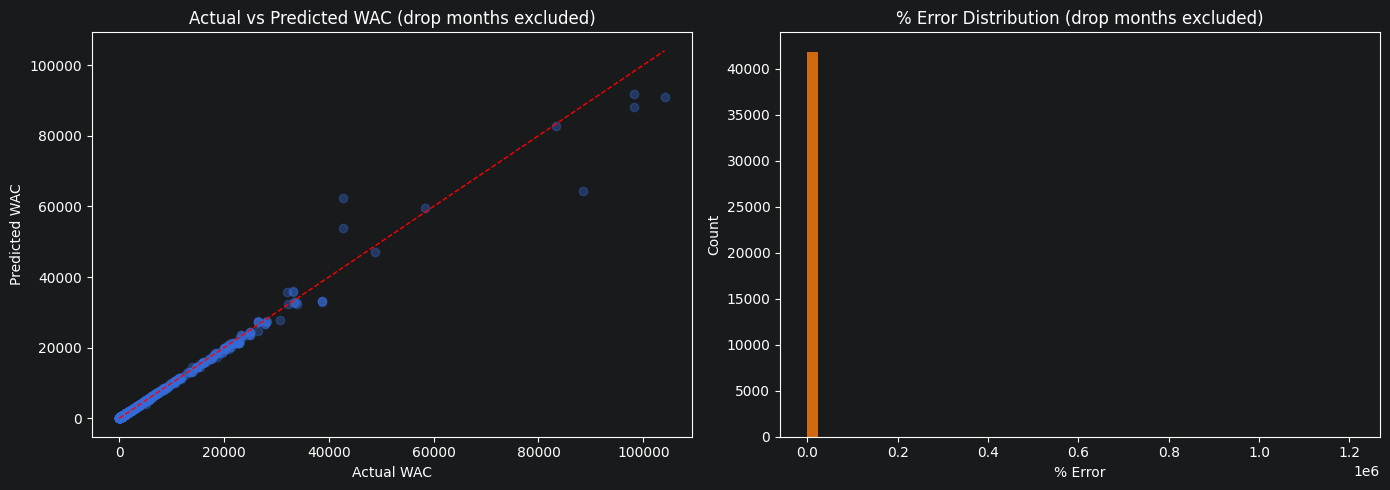

In [7]:
# ── Exclude only the specific month where actual WAC dropped >5% MoM ──
# After a structural drop the history is snapped to actuals (cell 5),
# so subsequent months are scored normally.
DROP_THRESHOLD = -5.0  # percent

prev_actual = (
    df[['COPA_MTRL_NUM','WAC_PRICE_COPA_DATE','BASELINE_WAC_PRICE']]
    .groupby(['COPA_MTRL_NUM','WAC_PRICE_COPA_DATE'], as_index=False)
    .agg({'BASELINE_WAC_PRICE':'min'})
    .copy()
)
prev_actual['WAC_PRICE_COPA_DATE'] = prev_actual['WAC_PRICE_COPA_DATE'] + pd.DateOffset(months=1)
prev_actual = prev_actual.rename(columns={'BASELINE_WAC_PRICE':'PREV_ACTUAL_WAC'})

forecast_df = forecast_df.merge(prev_actual, on=['COPA_MTRL_NUM','WAC_PRICE_COPA_DATE'], how='left')
forecast_df['MOM_ACTUAL_CHG_PCT'] = (forecast_df['ACTUAL_WAC'] / forecast_df['PREV_ACTUAL_WAC'] - 1) * 100

eval_df = forecast_df[
    forecast_df['MOM_ACTUAL_CHG_PCT'].isna() | (forecast_df['MOM_ACTUAL_CHG_PCT'] >= DROP_THRESHOLD)
].copy()

n_excl_rows = len(forecast_df) - len(eval_df)
n_excl_mtrls = forecast_df.loc[
    forecast_df['MOM_ACTUAL_CHG_PCT'] < DROP_THRESHOLD, 'COPA_MTRL_NUM'
].nunique()
print(f"Excluded {n_excl_rows:,} drop month(s) across {n_excl_mtrls} materials (actual drop > {abs(DROP_THRESHOLD):.0f}% MoM)")
print(f"Evaluation rows : {len(eval_df):,} of {len(forecast_df):,}")

eval_df['ABS_ERROR'] = (eval_df['ACTUAL_WAC'] - eval_df['PRED_WAC']).abs()
eval_df['PCT_ERROR'] = np.where(
    eval_df['ACTUAL_WAC'] != 0,
    (eval_df['PRED_WAC'] - eval_df['ACTUAL_WAC']) / eval_df['ACTUAL_WAC'] * 100,
    np.nan
)

overall_wape = eval_df['ABS_ERROR'].sum() / eval_df['ACTUAL_WAC'].abs().sum() * 100
overall_mae  = mean_absolute_error(eval_df['ACTUAL_WAC'], eval_df['PRED_WAC'])
median_ae    = eval_df['ABS_ERROR'].median()

summary_table = pd.DataFrame({
    'Metric': ['Dollar WAPE (%)', 'MAE', 'Median AE'],
    'Value':  [overall_wape, overall_mae, median_ae]
})
print(summary_table.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
scatter_sample = eval_df.sample(min(2000, len(eval_df)), random_state=42)
axes[0].scatter(scatter_sample['ACTUAL_WAC'], scatter_sample['PRED_WAC'], alpha=0.35)
min_wac = min(scatter_sample['ACTUAL_WAC'].min(), scatter_sample['PRED_WAC'].min())
max_wac = max(scatter_sample['ACTUAL_WAC'].max(), scatter_sample['PRED_WAC'].max())
axes[0].plot([min_wac, max_wac], [min_wac, max_wac], 'r--', linewidth=1)
axes[0].set_title('Actual vs Predicted WAC (drop months excluded)')
axes[0].set_xlabel('Actual WAC')
axes[0].set_ylabel('Predicted WAC')
axes[1].hist(eval_df['PCT_ERROR'].dropna(), bins=50, color='tab:orange', alpha=0.8)
axes[1].set_title('% Error Distribution (drop months excluded)')
axes[1].set_xlabel('% Error')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()


 REVENUE_RANK           MTRL_NUM                  MATERIAL_NAME   ACTUAL_WAC     PRED_WAC     WAPE
            1 000000000003796539     HUMIRA CF PEN 40MG/0.4ML 2  6922.620000  6863.418615 0.855188
            2 000000000002013282    ELIQUIS TAB 5MG          60   594.215000   644.465927 8.543273
            3 000000000001618990       STELARA PFS 90MG/1.0ML 1 27724.360000 26679.191702 3.867124
            4 000000000001554849    DUPIXENT INJ 300MG/2ML    2  3785.041667  3771.429862 1.171609
            5 000000000002324978     SKYRIZI INJ150MG/ML SD PEN 20909.532500 20414.940542 2.365390
            6 000000000001550797    KEYTRUDA SDV 100MG/4ML    2 11338.480000 11264.500856 0.957683
            7 000000000003979291          RINVOQ ER TAB 15MG 30  6405.608333  6444.835716 1.638820
            8 000000000003760550    BIKTARVY TAB 50/200/25MG 30  3979.380000  3953.022170 1.307861
            9 000000000003977964 ENBREL SURE CLICK 50MG/ML    4  7450.125000  7306.441848 2.076095
          

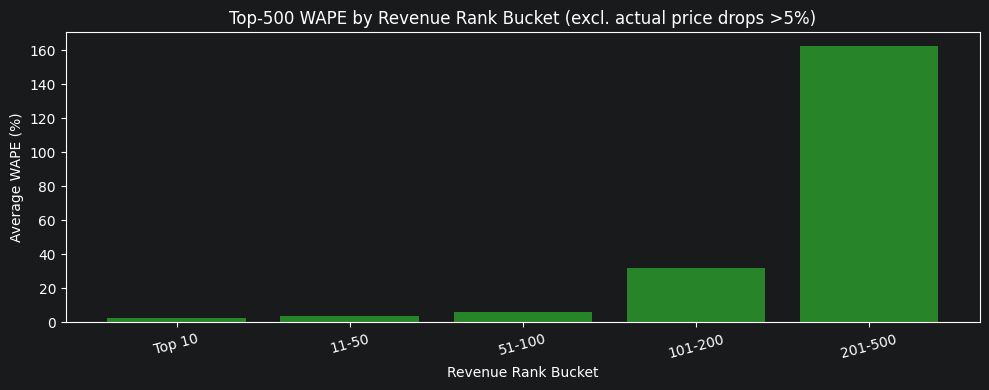

In [8]:
top500 = pd.read_csv(
    f'{BASE_PATH}/Top_500_revenueproducts.csv',
    usecols=['MTRL_NUM', 'REVENUE_RANK', 'MATERIAL_NAME', 'SELL_DSCR']
)
top500['MTRL_NUM'] = top500['MTRL_NUM'].astype(str).str.zfill(18)
top500 = top500.sort_values(['REVENUE_RANK', 'MTRL_NUM']).drop_duplicates(subset=['MTRL_NUM'])

top500_forecast = top500.merge(eval_df, left_on='MTRL_NUM', right_on='COPA_MTRL_NUM', how='inner')

def material_wape(group):
    return pd.Series({
        'ACTUAL_WAC': group['ACTUAL_WAC'].mean(),
        'PRED_WAC': group['PRED_WAC'].mean(),
        'WAPE': group['ABS_ERROR'].sum() / group['ACTUAL_WAC'].abs().sum() * 100
    })

top500_material_eval = (
    top500_forecast
    .groupby(['REVENUE_RANK', 'MTRL_NUM', 'MATERIAL_NAME'], as_index=False)
    .apply(material_wape)
    .reset_index(drop=True)
    .sort_values('REVENUE_RANK')
)

print(top500_material_eval.head(20).to_string(index=False))

bucket_order = ['Top 10', '11-50', '51-100', '101-200', '201-500']
top500_material_eval['RANK_BUCKET'] = pd.cut(
    top500_material_eval['REVENUE_RANK'],
    bins=[0, 10, 50, 100, 200, 500],
    labels=bucket_order,
    include_lowest=True
)
bucket_eval = (
    top500_material_eval
    .groupby('RANK_BUCKET', observed=False)['WAPE']
    .mean()
    .reindex(bucket_order)
    .reset_index()
)

plt.figure(figsize=(10, 4))
plt.bar(bucket_eval['RANK_BUCKET'].astype(str), bucket_eval['WAPE'], color='tab:green', alpha=0.8)
plt.title('Top-500 WAPE by Revenue Rank Bucket (excl. actual price drops >5%)')
plt.xlabel('Revenue Rank Bucket')
plt.ylabel('Average WAPE (%)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


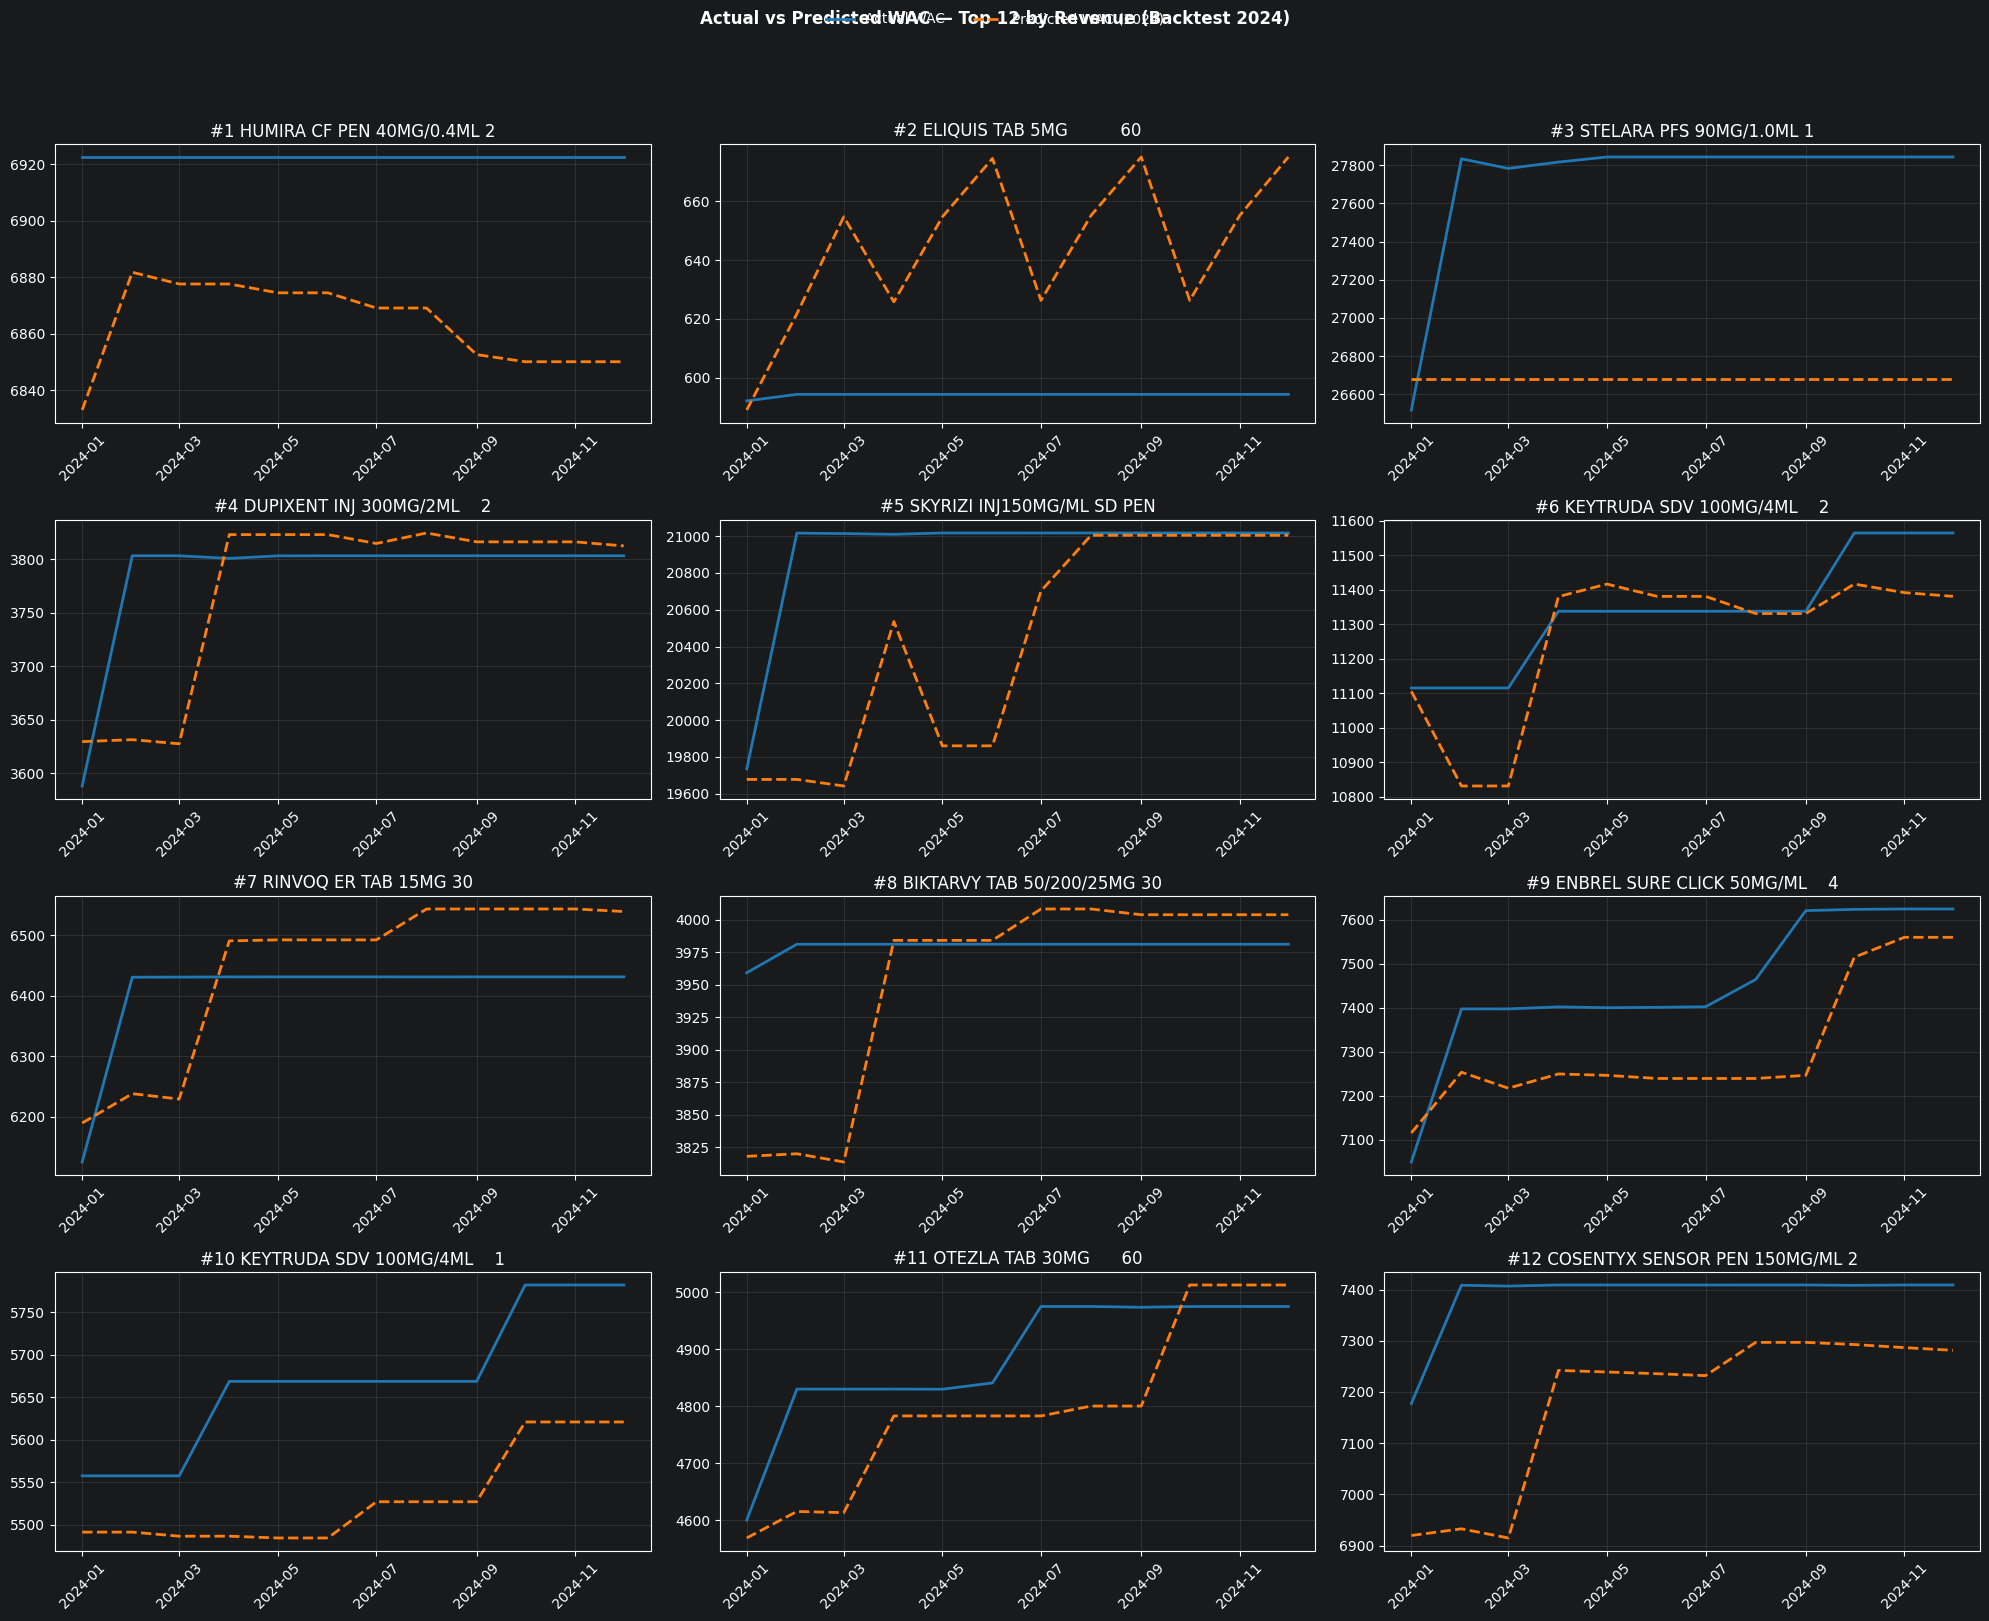

In [9]:
top12_materials = top500.sort_values('REVENUE_RANK').head(12)
actual_plot_df = df[
    (df['COPA_MTRL_NUM'].isin(top12_materials['MTRL_NUM']))
    & (df['WAC_PRICE_COPA_DATE'] >= FORECAST_START)
    & (df['WAC_PRICE_COPA_DATE'] < FORECAST_END)
].copy()

fig, axes = plt.subplots(4, 3, figsize=(20, 16), sharex=False)
axes = axes.flatten()

for ax, (_, material_row) in zip(axes, top12_materials.iterrows()):
    material = material_row['MTRL_NUM']
    rank = material_row['REVENUE_RANK']
    label = material_row['MATERIAL_NAME']

    actual_series = actual_plot_df[actual_plot_df['COPA_MTRL_NUM'] == material].sort_values('WAC_PRICE_COPA_DATE')
    pred_series = forecast_df[forecast_df['COPA_MTRL_NUM'] == material].sort_values('WAC_PRICE_COPA_DATE')

    ax.plot(actual_series['WAC_PRICE_COPA_DATE'], actual_series['BASELINE_WAC_PRICE'], color='tab:blue', linewidth=2, label='Actual WAC')
    ax.plot(pred_series['WAC_PRICE_COPA_DATE'], pred_series['PRED_WAC'], color='tab:orange', linestyle='--', linewidth=2, label='Predicted WAC (2024)')
    ax.set_title(f'#{rank} {label[:35]}')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(alpha=0.2)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False)
plt.suptitle('Actual vs Predicted WAC — Top 12 by Revenue (Backtest 2024)', fontweight='bold', y=1.01)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()